<a href="https://colab.research.google.com/github/chinh-hoangduc/QuantEcon-exercises/blob/main/huggett1996.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install jax

In [4]:
from typing import NamedTuple
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.scipy as jsp
import jax
import quantecon as qe

In [ ]:
class Household(NamedTuple):
    β: float
    R: int
    s_grid: jnp.ndarray
    a_grid: jnp.ndarray
    z_grid: jnp.ndarray
    Π: jnp.ndarray
    Z: jnp.ndarray
    μ: jnp.ndarray
    y_bar: jnp.ndarray
    L: float
    V_term: jnp.ndarray

def create_household(
    uncertain_life: bool = True,
    N: int = 79,
    R: int = 46,
    n: float = 0.012,
    γ: float = 0.96,
    σ_y1: float = jnp.sqrt(0.38),
    σ_ε: float = jnp.sqrt(0.045),
    a_min: float = 1e-3,
    a_max: float = 15,
    N_a: int = 150,
    y_bar = jnp.asarray([0.592811536, 0.67894433, 0.752769162, 0.801036512, 0.856499145, 0.897712519, 0.931852187, 0.964435645, 1.00863726, 1.042261306, 1.07452855, 1.090198545, 1.120688638, 1.139208551, 1.150134723, 1.164495963, 1.178630128, 1.192546884, 1.192546884, 1.195993173, 1.195993173, 1.195993173, 1.195993173, 1.192546884, 1.192546884, 1.189087573, 1.185615104, 1.185615104, 1.182129337, 1.178630128, 1.168050403, 1.15734436, 1.150134723, 1.131847939, 1.113167962, 1.090198545, 1.082400485, 1.062577797, 1.042261306, 1.021415386, 0.977969892, 0.907637678, 0.856499145, 0.801036512, 0.693134272, 0.592811536, 0.497097048, 0.398192886, 0.333901242, 0.294684864, 0.247105475, 0.182871784, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068, 0.049787068])
) -> Household:

    if uncertain_life == True:
        β = 1.011
        s_grid = jnp.zeros(N)
        print("Please switch to certain lifetime")
    else:
        β = 0.994
        s_grid = jnp.ones(N)

    # share of population at each age (1 x N)
    μ = np.zeros(len(s_grid))
    μ[0] = 1
    for i in range(len(s_grid) - 1):
        μ[i+1] = s_grid[i+1]*μ[i] / (1+n)
    μ = μ/np.sum(μ)
    μ = jnp.asarray(μ)

    # asset grid
    a_grid = jnp.linspace(a_min, a_max, N_a)

    # shock grid (1 x 8)
    z_grid = jnp.linspace(-4*σ_y1, 4*σ_y1, 7)
    z_grid = jnp.append(z_grid, 6*σ_y1)

    # Customised transition matrix (8 x 8)
    Π = np.zeros((len(z_grid), len(z_grid)))
    for i, zi in enumerate(z_grid):
        Π[i, 0] = jax.scipy.stats.norm.cdf((z_grid[0] + z_grid[1])/2, zi*γ, σ_ε)
        for j, zj in list(enumerate(z_grid))[1:-1]:
            Π[i, j] = jax.scipy.stats.norm.cdf((z_grid[j] + z_grid[j+1])/2, zi*γ, σ_ε) - jax.scipy.stats.norm.cdf((z_grid[j-1] + z_grid[j])/2, zi*γ, σ_ε)
        Π[i, -1] = 1 - jax.scipy.stats.norm.cdf((z_grid[-1] + z_grid[-2])/2, zi*γ, σ_ε)
    Π = jnp.asarray(Π)

    # initial shock distribution
    z0 = np.zeros(len(z_grid))
    z0[0] = jax.scipy.stats.norm.cdf((z_grid[0] + z_grid[1])/2, 0, σ_y1)
    for i, zi in list(enumerate(z_grid))[1:-1]:
        z0[i] = jax.scipy.stats.norm.cdf((z_grid[i] + z_grid[i+1])/2, 0, σ_y1) - jax.scipy.stats.norm.cdf((z_grid[i-1] + z_grid[i])/2, 0, σ_y1)
    z0[-1] = 1 - jax.scipy.stats.norm.cdf((z_grid[-1] + z_grid[-2])/2, 0, σ_y1)

    # shock distribution at each age (N x 8)
    Z = np.zeros((N, len(z_grid)))
    Z[0, :] = z0
    for i in range(N-1):
        Z[i+1, :] = Z[i, :] @ Π
    Z = jnp.asarray(Z)

    # calculate total labour supply
    e = y_bar[:, None] * jnp.exp(z_grid[None, :])
    L = μ @ jnp.sum(e * Z, axis=1)

    # Terminal value
    V_term = jnp.zeros((len(a_grid), len(z_grid)))

    return Household(β, R, s_grid, a_grid, z_grid, Π, Z, μ, y_bar, L, V_term)

In [ ]:
household = create_household(uncertain_life = False)

np.sum(household.Π, axis=1)

household.L

Array(1.0685232, dtype=float32)

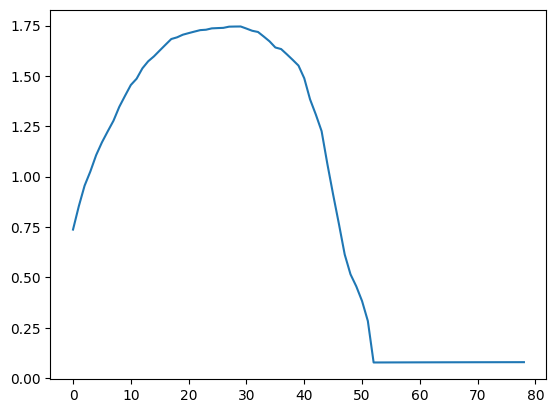

In [ ]:
E_L = jnp.sum((household.y_bar[:, None] * jnp.exp(household.z_grid[None, :])) * household.Z, axis=1)

fig, ax = plt.subplots()
ax.plot(range(79), E_L)

In [ ]:
class Firm(NamedTuple):
    α: float
    δ: float
    A: float

def create_firm(
    α: float = 0.36,
    δ: float = 0.06,
    A: float = 1
) -> Firm:
    return Firm(α, δ, A)

firm = create_firm()

In [ ]:
class Price(NamedTuple):
    r: float
    w: float
    τ: float
    θ: float

def create_price(
    r: float,
    w: float,
    τ: float = 0.2378,
    θ: float = 0.1
):
    return Price(r, w, τ, θ)

price = create_price(r=0.05, w=1)

In [ ]:
def u(c, σ = 1.5):
    return c**(1 - σ) / (1 - σ)

def interest(K, L, firm):
    α, δ, A = firm
    return α*A*(K/L)**(α-1) - δ

def wage(K, L, firm):
    α, δ, A = firm
    return (1-α)*A*(K/L)**(α)

In [ ]:
def populate_R(
    j: int,
    household: Household,
    price: Price
):
    r, w, τ, θ = price
    β, R, s_grid, a_grid, z_grid, Π, Z, μ, y_bar, L, V_term = household

    num_state = a_grid.size * z_grid.size
    num_action = a_grid.size

    a = jnp.reshape(a_grid, (a_grid.size, 1, 1))
    z = jnp.reshape(z_grid, (1, z_grid.size, 1))
    ap = jnp.reshape(a_grid, (1, 1, a_grid.size))

    c = (1 + r*(1-τ))*a + (1 - θ - τ)* w * y_bar[j] * jnp.exp(z) - ap

    return jnp.reshape(jnp.where(c > 0, u(c), (len(a_grid * len(z_grid))), -jnp.inf), (num_state, num_action))

def populate_Q(
    household: Household
):
    β, R, s_grid, a_grid, z_grid, Π, Z, μ, y_bar, L, V_term = household

    num_state = a_grid.size * z_grid.size
    num_action = a_grid.size

    Q = jsp.linalg.block_diag(*[Π.T]*a_grid.size)
    Q = jnp.reshape((num_state, num_action, z_grid.size))
    Q = jnp.tile(Q, a_grid.size).T

    return Q

In [15]:
# @title
Pi = np.array([[0.8, 0.2],
 [0.3, 0.7]])

Que1 = jsp.linalg.block_diag(*[Pi.T] * 3)
Que2 = Que1.reshape((6, 3, 2))
Que3 = jnp.tile(Que2, 3)
Que4 = Que3.T

In [2]:
def backward_op(
    household: Household,
    firm: Firm,
    price: Price
):


    def bellman_operator_j(V_next, j):
        "Solve household optimization problem at age j given Vj+1"

        Rj = populate_R(j, r, w, τ, δ, household)
        vals = Rj + β * Q.dot(V_next)
        σ_j = jnp.argmax(vals, axis=1)
        V_j = vals[jnp.arange(num_state), σ_j]

        return V_j, (V_j, σ_j)

NameError: name 'Household' is not defined